## Agent WorkFlow Example

In [1]:
import os
from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

def get_weather(city:str)-> str:
    """Get the weather for a city."""
    return f"The weather in {city} is sunny."

agent = create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt="You are a helpful assistant."
)
agent

response = agent.invoke({"messages":[{"role":"user","content":"What is the weather in chennai?"}]})
response["messages"][-1].content

'The weather in Chennai is sunny.'

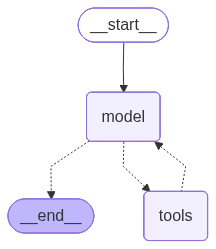

In [2]:

agent = create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt="You are a helpful assistant."
)
agent


## Models Integration with OpenAI,Google,Gemini and Groq

In [3]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model

load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

#model1 = init_chat_model(model="gpt-4.1",model_provider-"openai")
#model1
#response1 = model1.invoke("Hello How are you?")
#response1

model2 = init_chat_model(model="gemini-2.5-flash",model_provider="google_genai")
model2
response2 = model2.invoke("Why do parrots talk?")
response2.content

model3 = init_chat_model(model="llama-3.3-70b-versatile",model_provider="groq")
model3
response3 = model3.invoke("Who am i?")
response3


AIMessage(content="Unfortunately, I don't have any information about you, so I'll have to ask some questions to try to figure out who you are.\n\nTo start, are you a person, a character, or something else entirely?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 39, 'total_tokens': 84, 'completion_time': 0.149140123, 'completion_tokens_details': None, 'prompt_time': 0.006724095, 'prompt_tokens_details': None, 'queue_time': 0.051045824, 'total_time': 0.155864218}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0375-19b8-7811-9f18-8279caaa4130-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 39, 'output_tokens': 45, 'total_tokens': 84})

## Streaming 
Most model can stream their output while it is being generated. By displaying output progressive,streaming significantly improves user experience,particularly for longer responses. Calling stream() return an iterator that yeild output chunks as they are produced. You can use a loop to process each chunk in real-time.

In [4]:
for chunk in model2.stream("Write me a 200 words paragraph on Artificial Intelligence"):
    print(chunk.text, end="|", flush=True)

Artificial Intelligence (AI) represents the simulation of human intelligence processes by machines|, particularly computer systems. At its core, AI empowers systems to learn from data, reason, solve problems, understand language, recognize patterns, and make decisions, often performing tasks that traditionally require human cognitive abilities. This sophisticated technology encompasses various sub|-fields like machine learning, deep learning, natural language processing (NLP), and computer vision, each contributing to its expansive capabilities.

Today, AI is deeply integrated into our daily lives and revolutionizing industries worldwide. From personalized recommendations on streaming| services and voice assistants like Siri and Alexa, to sophisticated diagnostic tools in healthcare, autonomous vehicles, and predictive analytics in finance, AI is enhancing efficiency, driving innovation, and transforming how we work and live. While promising immense potential for solving complex| globa

In [5]:
for chunk in model2.stream("Why do parrots have colorful features?"):
    print(chunk.text, end="|", flush=True)

Parrots are renowned for their dazzling array of colors, and like many striking features in the animal kingdom, this serves| several important evolutionary purposes. It's not just one reason, but a combination of factors related to their biology, social behavior, and environment.

Here are the main reasons why parrots have colorful features:

1.  **Sexual Selection| and Attracting Mates:**
    *   **Display of Health and Fitness:** Bright, vibrant plumage is often a signal of a bird's health and genetic fitness. A parrot that can acquire the necessary nutrients (especially carotenoids from| its diet) to produce strong pigments, or maintain its structural feather integrity, is likely a healthy individual. Potential mates will be more attracted to these signals, as it suggests good genes and the ability to find food and resist parasites.
    |*   **Species Recognition:** In a diverse tropical environment with many different bird species, distinct color patterns help parrots recognize mem

## Batch
BAtching a collection of independent requests to a model can significantly improve performance and reduce cost, as the processing can be done in parallel.

In [ ]:
responses = model2.batch([
    "Why do parrots have colorful features?",
    "How do airplane fly?",
    "what is quantum computing?"
])
for res in responses:
    print(res)

model2.batch([
    "Why do parrots have colorful features?",
    "How do airplane fly?",
    "what is quantum computing?"
],
config={
    'max_concurrency':5
}
)

content='Parrots are renowned for their vibrant and diverse plumage, and this stunning coloration serves a variety of important evolutionary purposes, stemming from a combination of biological mechanisms:\n\n### How They Get Their Colors:\n\n1.  **Pigments:**\n    *   **Melanins:** Produce blacks, browns, and grays. These are produced by the bird\'s own body.\n    *   **Carotenoids:** Produce reds, yellows, and oranges. These pigments cannot be synthesized by the bird and must be obtained through their diet (e.g., from fruits, seeds, and nectar). The availability of carotenoids in their diet directly influences the brightness and intensity of these colors, making them a "honest signal" of health and foraging ability.\n    *   **Psittacofulvins:** Unique to parrots, these pigments produce a range of reds, oranges, and yellows. Unlike carotenoids, psittacofulvins are synthesized by the parrots themselves.\n\n2.  **Structural Colors:**\n    *   **Blues and Greens:** These colors are not d